# Shape Similarity using Geometric Moments (Hu Moments)

We can determine whether two 2D shapes are similar by comparing their **Hu invariant moments**.

## Method
1. Convert each image to a binary mask (shape = white, background = black).
2. Compute geometric moments and Hu moments with OpenCV.
3. Apply log transform to Hu moments for numerical stability:
   \[
   h'_i = -\operatorname{sign}(h_i)\log_{10}(|h_i| + \epsilon)
   \]
4. Compute distance between the two 7D Hu vectors (L1/L2).
5. If distance < threshold, classify as **similar**; otherwise **not similar**.

Hu moments are invariant to translation, scale, and rotation, which makes them suitable for shape matching.

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


def preprocess_shape(image, threshold=127):
    """Convert input image to a clean binary mask with white foreground."""
    if image is None:
        raise ValueError("Input image is None")

    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()

    _, binary = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)

    # Ensure shape is white foreground. If mostly white, invert.
    white_ratio = np.mean(binary > 0)
    if white_ratio > 0.6:
        binary = cv2.bitwise_not(binary)

    kernel = np.ones((3, 3), np.uint8)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel, iterations=1)
    return binary


def hu_moment_vector(binary_mask, eps=1e-12):
    moments = cv2.moments(binary_mask)
    hu = cv2.HuMoments(moments).flatten()
    hu_log = -np.sign(hu) * np.log10(np.abs(hu) + eps)
    return hu_log


def largest_contour(binary_mask):
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        raise ValueError("No contour found in shape image.")
    return max(contours, key=cv2.contourArea)


def shape_similarity_score(img1, img2, threshold=0.03):
    """
    Hu-moment based shape similarity using contour matching.

    Returns:
      similar (bool), score (float), hu1 (np.ndarray), hu2 (np.ndarray), b1, b2
    Lower score = more similar.
    """
    b1 = preprocess_shape(img1)
    b2 = preprocess_shape(img2)

    c1 = largest_contour(b1)
    c2 = largest_contour(b2)

    # Uses Hu moments internally (invariant to translation/scale/rotation)
    score = float(cv2.matchShapes(c1, c2, cv2.CONTOURS_MATCH_I1, 0.0))

    hu1 = hu_moment_vector(b1)
    hu2 = hu_moment_vector(b2)

    similar = score < threshold
    return similar, score, hu1, hu2, b1, b2


In [5]:
# Demo with synthetic shapes (works in Colab and local notebook)
canvas_size = 256

# Shape A: circle
shape_a = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
cv2.circle(shape_a, (128, 128), 60, 255, -1)

# Shape B: transformed version of circle (should be similar)
M = cv2.getRotationMatrix2D((128, 128), 32, 0.85)
M[0, 2] += 10  # tx
M[1, 2] += -12 # ty
shape_b = cv2.warpAffine(shape_a, M, (canvas_size, canvas_size), flags=cv2.INTER_NEAREST)

# Shape C: rectangle (should be dissimilar to circle)
shape_c = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
cv2.rectangle(shape_c, (70, 80), (190, 170), 255, -1)

sim_ab, score_ab, hu_a, hu_b, bin_a, bin_b = shape_similarity_score(shape_a, shape_b, threshold=0.03)
sim_ac, score_ac, _, hu_c, _, bin_c = shape_similarity_score(shape_a, shape_c, threshold=0.03)

print("A vs B (same shape under affine transform)")
print(f"Similar: {sim_ab}, score: {score_ab:.6f}")
print()
print("A vs C (different shapes)")
print(f"Similar: {sim_ac}, score: {score_ac:.6f}")

print("\nHu moments (log scale, diagnostic):")
print("A:", np.round(hu_a, 4))
print("B:", np.round(hu_b, 4))
print("C:", np.round(hu_c, 4))

A vs B (same shape under affine transform)
Similar: True, score: 0.000046

A vs C (different shapes)
Similar: False, score: 0.062163

Hu moments (log scale, diagnostic):
A: [3.2047 0.     0.     0.     0.     0.     0.    ]
B: [3.2047 0.     0.     0.     0.     0.     0.    ]
C: [3.1673 7.4482 0.     0.     0.     0.     0.    ]


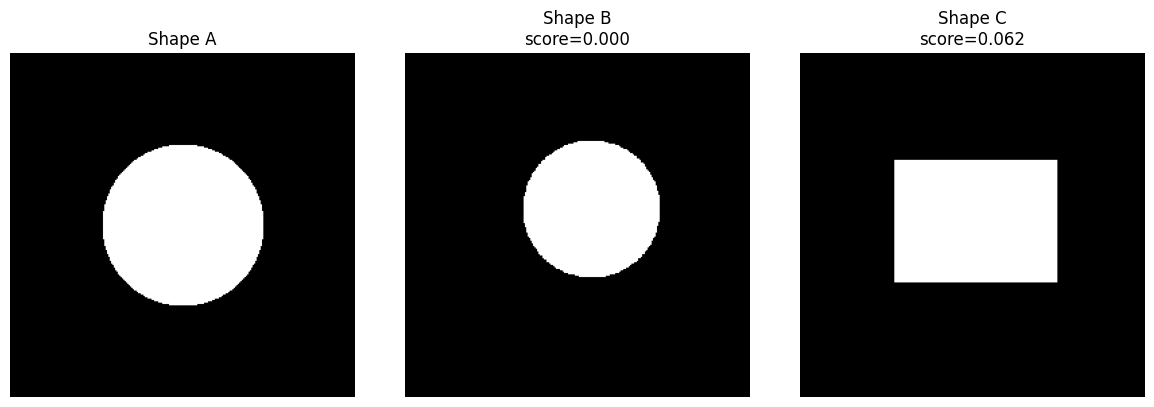

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(bin_a, cmap="gray")
ax[0].set_title("Shape A")
ax[0].axis("off")

ax[1].imshow(bin_b, cmap="gray")
ax[1].set_title(f"Shape B\nscore={score_ab:.3f}")
ax[1].axis("off")

ax[2].imshow(bin_c, cmap="gray")
ax[2].set_title(f"Shape C\nscore={score_ac:.3f}")
ax[2].axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Colab-friendly usage on real images
# 1) In Colab, run this cell and upload two shape images.
# 2) It prints whether the shapes are similar.


def compare_shape_files(path1, path2, threshold=0.03):
    img1 = cv2.imread(path1, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(path2, cv2.IMREAD_GRAYSCALE)
    if img1 is None or img2 is None:
        raise FileNotFoundError("Could not read one or both image paths.")

    similar, score, _, _, b1, b2 = shape_similarity_score(img1, img2, threshold=threshold)
    print(f"Similar: {similar} | score: {score:.6f} | threshold: {threshold}")

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(b1, cmap="gray")
    plt.title("Shape 1 (binary)")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(b2, cmap="gray")
    plt.title("Shape 2 (binary)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


# Optional: uncomment this block in Google Colab
# from google.colab import files
# uploaded = files.upload()  # upload two images
# names = list(uploaded.keys())
# compare_shape_files(names[0], names[1], threshold=0.03)

# Local example usage:
# compare_shape_files("shape1.png", "shape2.png", threshold=0.03)